In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
data_dir="/content/drive/MyDrive/Mango"

In [4]:
image_height=128
image_width=128
batch_sze=32

In [5]:
dataset=image_dataset_from_directory(data_dir,
                                     image_size=(image_height,image_width),
                                     batch_size=batch_sze)

Found 3500 files belonging to 7 classes.


In [6]:
print(dataset.class_names)
class_label=dataset.class_names

['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Sooty Mould']


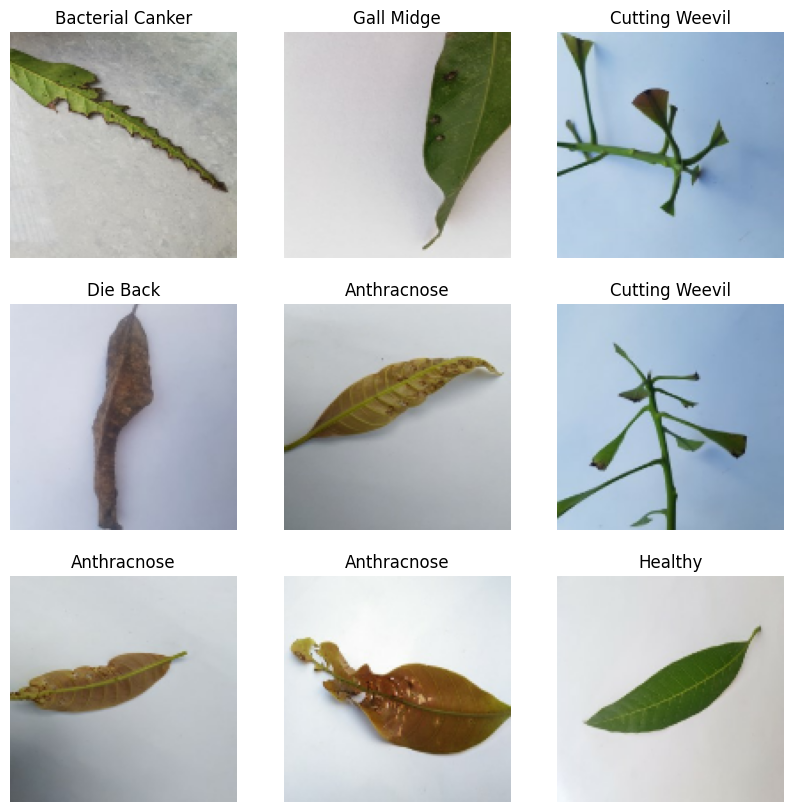

In [7]:
plt.figure(figsize=(10,10))
for images, labels in dataset.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_label[labels[i].numpy()])
    plt.axis("off")
plt.show()

In [8]:
imagez, labelz = next(iter(dataset))#Gives first 32 batches only

Text(0.5, 1.0, 'Healthy')

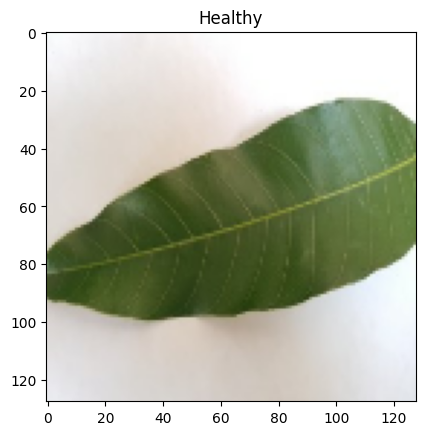

In [9]:
plt.imshow(imagez[24].numpy().astype('uint8'))
plt.title(class_label[labelz[24].numpy()])

In [10]:
dataset = dataset.map(lambda image, label: (image / 255.0, label))
dataset = dataset.cache().shuffle(1000).prefetch(tf.data.AUTOTUNE)

In [11]:
from tensorflow.keras import layers

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [12]:
latent_dim = 32

encoder_inputs = layers.Input(shape=(image_height, image_width, 3))
x = layers.Conv2D(32, 3, strides=2, activation='relu', padding='same')(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, activation='relu', padding='same')(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)
z = Sampling()([z_mean, z_log_var])

encoder = tf.keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 32,    │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 65536)     │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │  8,388,736 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      4,128 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 32)        │          0 │ dense_1[0][0],    │
│                     │                   │            │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,416,384 (32.11 MB)

 Trainable params: 8,416,384 (32.11 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
latent_inputs = layers.Input(shape=(latent_dim,))
x = layers.Dense((image_height // 4) * (image_width // 4) * 64, activation='relu')(latent_inputs)
x = layers.Reshape((image_height // 4, image_width // 4, 64))(x)
x = layers.Conv2DTranspose(64, 3, strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(32, 3, strides=2, activation='relu', padding='same')(x)
decoder_outputs = layers.Conv2DTranspose(3, 3, activation='sigmoid', padding='same')(x)

decoder = tf.keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()


Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 65536)          │     2,162,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 64, 64, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 128, 128, 32)   │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 128, 128, 3)    │           867 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,218,947 (8.46 MB)

 Trainable params: 2,218,947 (8.46 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = tf.keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = tf.keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = tf.keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        # Split the data into images and labels
        image, label = data

        with tf.GradientTape() as tape:
            # Pass only the image to the encoder
            z_mean, z_log_var, z = self.encoder(image)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    tf.keras.losses.binary_crossentropy(image, reconstruction), axis=(1, 2) # Use image instead of data
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [15]:
vae = VAE(encoder, decoder)
vae.compile(optimizer=tf.keras.optimizers.Adam())
vae.fit(dataset, epochs=20)


Epoch 1/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 566s 2s/step - kl_loss: 22.0873 - loss: 10380.5010 - reconstruction_loss: 10358.4131
Epoch 2/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - kl_loss: 37.3749 - loss: 9653.3320 - reconstruction_loss: 9615.9580
Epoch 3/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 207s 2s/step - kl_loss: 46.8650 - loss: 9360.2051 - reconstruction_loss: 9313.3398
Epoch 4/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - kl_loss: 49.5767 - loss: 9208.1719 - reconstruction_loss: 9158.5957
Epoch 5/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 166s 2s/step - kl_loss: 54.0722 - loss: 9091.4893 - reconstruction_loss: 9037.4180
Epoch 6/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 194s 1s/step - kl_loss: 55.2750 - loss: 9064.3682 - reconstruction_loss: 9009.0928
Epoch 7/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 160s 1s/step - kl_loss: 57.4293 - loss: 9008.7021 - reconstruction_loss: 8951.2725
Epoch 8/20
110/110 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - kl_loss: 56.6988 - loss: 8995.1045 - reconstruction_loss: 8938.4062
Epoch 9/20
110

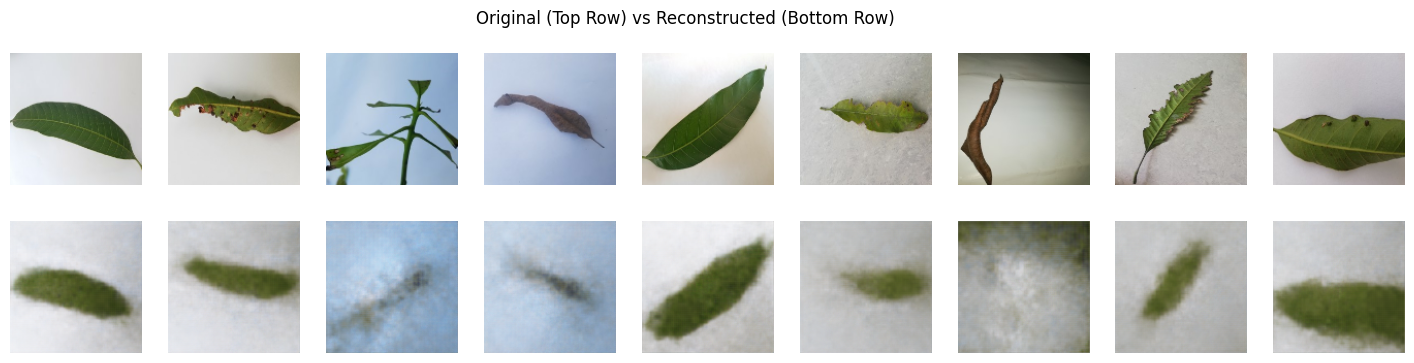

In [17]:
import matplotlib.pyplot as plt

for batch in dataset.take(1):
    # Accessing only the images using batch[0] and slicing
    original = batch[0][:9]
    z_mean, z_log_var, z = encoder(original)
    reconstructed = decoder(z)

    plt.figure(figsize=(18, 4))
    for i in range(9):
        # Original
        ax = plt.subplot(2, 9, i + 1)
        plt.imshow(original[i].numpy())
        plt.axis("off")
        # Reconstructed
        ax = plt.subplot(2, 9, i + 10)
        plt.imshow(reconstructed[i].numpy())
        plt.axis("off")
    plt.suptitle("Original (Top Row) vs Reconstructed (Bottom Row)")
    plt.show()

In [18]:
import tensorflow.image as tfi

ssim_scores = []

for batch in dataset.take(1):
    # original should only contain the images from the batch
    original, _ = batch  # Unpack the batch into images and labels, ignoring labels
    original = original[:9] # Selecting the first 9 images for SSIM calculation
    reconstructed = vae.decoder(vae.encoder(original)[2])

    for i in range(len(original)):
        ssim = tfi.ssim(original[i], reconstructed[i], max_val=1.0)
        ssim_scores.append(ssim.numpy())

print("Average SSIM:", sum(ssim_scores) / len(ssim_scores))

Average SSIM: 0.6782528


In [22]:
!pip install --upgrade tensorflow-probability

In [27]:
import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
from scipy import linalg

# Load the InceptionV3 feature extractor from TF Hub
inception = hub.load("https://tfhub.dev/google/imagenet/inception_v3/feature_vector/5")

# Preprocess images for InceptionV3 (resize to 299x299 and scale to 0–255)
def preprocess_for_fid(images):
    images = tf.image.resize(images, [299, 299])
    return images * 255.0  # Convert normalized [0,1] back to pixel range

# Function to calculate FID
def calculate_fid(real_features, fake_features):
    # Convert to numpy
    real_features = real_features.numpy()
    fake_features = fake_features.numpy()

    # Compute means and covariances
    mu_real = np.mean(real_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)

    mu_fake = np.mean(fake_features, axis=0)
    sigma_fake = np.cov(fake_features, rowvar=False)

    # Calculate sum of squared difference between means
    diff = mu_real - mu_fake
    diff_squared = np.sum(diff**2)

    # Compute sqrt of product of covariances
    covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)

    # Handle imaginary numbers due to numerical instability
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff_squared + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

# Run for one batch
for real_batch in dataset.take(1):
    real_images, _ = real_batch
    real_images = real_images[:50]

    z_mean, z_log_var, z = vae.encoder(real_images)
    fake_images = vae.decoder(z)

    real_images_fid = preprocess_for_fid(real_images)
    fake_images_fid = preprocess_for_fid(fake_images)

    real_features = inception(real_images_fid)
    fake_features = inception(fake_images_fid)

    fid_score = calculate_fid(real_features, fake_features)
    print("FID Score:", fid_score)


FID Score: 167467.36192658183
